# Data Engineering Take-Home Assignment: Nature Conservation & Geospatial Data

## Context
Assume you have been hired as a Data Engineer for an organization focused on nature conservation. The organization is working on a project to monitor and protect natural habitats using satellite data, wildlife sensor data, and geospatial information. Your task is to design and implement a data pipeline that ingests, processes, and analyzes this data to help identify areas needing immediate conservation attention as well as build a model that provides helpful insights related our organization's interests.

## Objective 

Your goal in this assessment is to showcase your curiousity and creativity to design rigorous models and derive interesting insights.  

You'll be given two tasks.

The first is a design task, in which we expect you to diagram and describe how you'd set up a process to injest this data from a live streamed source, assuming you are also paying montoring services to supply this data from scratch. Think about how you might transform and store the data efficiently for querying and analysis and feed it into your model. 

The second task will require you devise interesting questions from preliminary explorations of a subset of migration data, found alongside this notebook, and construct a rigorous model to answer them. Please demonstrate all of your process using this notebook, and most importantly your outputs. 




## Tasks

### 1) Design - Data Ingestion & Storage:
- **Ingestion**: Design and implement a solution to ingest data from three different sources: GeoJSON, CSV, and JSON.
- **Automation**: Ensure the pipeline can handle regular data updates (e.g., daily or hourly).
- **Storage**: Choose appropriate storage solutions for each dataset (e.g., relational database, NoSQL, cloud storage, or data lake). Provide justification for your choices.

### 2) Data Transformation & Analysis:
- **Data Parsing & Cleaning**: 
  - Parse and clean the wildlife tracking data (CSV) and geospatial data (GeoJSON) to ensure consistency.
  - Ensure the data is ready for analysis by standardizing formats, removing errors, and handling missing values.

- **Exploratory Data Analysis**:
  - Investigate the data to understand key characteristics, distributions, and trends.

- **Behavioral Analysis**:
  - Identify more complex animal behaviors:
    - Determine when animals cross the boundaries of protected areas.
    - Analyze potential factors contributing to these crossings (e.g., time, weather, or environmental changes).
    - Calculate the total number of animal entries and exits from protected areas over time.

- **Advanced Insights**:
  - Identify migration paths or clustering patterns.
  - Build a predictive model to anticipate future animal movements or identify risk zones for endangered species.

### 3) Optional Bonus - Visualization/Reporting:
- Provide interactive visualizations to demonstrate your analysis, ideally within this notebook.

### Here are data sources you can use to build your analysis. 

- https://storage.googleapis.com/data-science-assessment/animal_events.csv
- https://storage.googleapis.com/data-science-assessment/animals.csv
- https://storage.googleapis.com/data-science-assessment/protected_areas.json
- https://storage.googleapis.com/data-science-assessment/satellites.json

## Deliverables
#### Design component:
- A clear description and diagrams for the architecture and tools you might used, including any cloud services, databases, or libraries (if applicable). During the discussion we'll go over different scenarios. 

#### Implementation:
- Code for the data pipeline that includes:
  - Data ingestion scripts or setup.
  - Transformation and processing logic.
  - Queries or outputs showcasing the results.
- (Optional) a visualization of the results.

## Data
### 1. **Animal Events - CSV** [Download link](https://storage.googleapis.com/data-science-assessment/animal_events.csv)

- Contains data on animal movement events with details like location and speed.
- **Key Columns**: `event_id`, `animal_id`, `timestamp`, `latitude`, `longitude`, `speed`.

---

### 2. **Animals - CSV** [Download link](https://storage.googleapis.com/data-science-assessment/animals.csv)

- Metadata about tracked animals, including species and conservation status.
- **Key Columns**: `animal_id`, `species`, `endangered`, `animal_type`, `preferred_landcover`.

---

### 3. **Protected Areas - GeoJSON** [Download link](https://storage.googleapis.com/data-science-assessment/protected_areas.json)

- Geospatial data representing protected areas with boundaries and metadata.
- **Key Fields**: `name`, `category`, `protected_area_id`, `geometry`.

---

### 4. **Satellite Metadata - JSON** [Download link](https://storage.googleapis.com/data-science-assessment/satellites.json)

- Metadata from satellite imagery, covering factors like cloud cover and resolution.
- **Key Fields**: `satellite_id`, `start_time`, `last_time`, `frequency`, `bounding_box`, `cloud_cover_percentage`, `resolution`.

---

## Evaluation Criteria

- **Data Engineering Skills**: How well the pipeline handles ingestion, transformation, and storage.
- **Geospatial Data Handling**: Ability to process geospatial data and perform spatial operations (e.g., joins, intersections).
- **Scalability & Efficiency**: The pipeline’s ability to handle larger datasets or more frequent updates.
- **Code Quality**: Structure, readability, and use of best practices.
- **Documentation**: Clear explanations of your approach and any assumptions made.
- **Bonus (Visualization/Reporting)**: Extra points for insightful data visualization or reporting.

## Set up

Feel free to set up this notebook using condo, or your own kernal / virtual environment. To make it easier, you can set up the notebook using this docker with the potentialy libraries you might need. 

#### To start using a prepared Docker image, 
- 1 navigate to this shared folder in your terminal, and then load up docker and run the docker file to pull in needed libraries

```bash
docker build -t geospatial-notebook .
docker run -p 8888:8888 -v $(pwd):/home/nobody/work geospatial-notebook
```


When the container runs, it will display a URL with a token (something like http://127.0.0.1:8888/?token=...). It will probably be something like http://127.0.0.1:8888/tree You can copy this URL into your browser, and you'll open to a Jupyter lab. Your existing notebook will be available inside the container under the work directory.

Anytime you want to work again, just run the following command to start the Docker container and access your notebooks:

```bash
docker run -p 8888:8888 -v $(pwd):/home/nobody/work geospatial-notebook
```

Please be sure your notebook runs by adding the needed dependencies to the requirements doc. I would encourage you to avoid external dependencies, like postgres setup for the implementation of your work so that the notebook work works without significant setup. You can demonstrate your knowledge of various infrastructure in your design submission. 

Critiques of this assignment are also welcomed and will contribute to this score. `


In [53]:
# Libraries you may or may not need
import pandas as pd
import geopandas as gpd
import shapely
import sqlalchemy
import psycopg2
import osgeo.gdal

from sklearn.cluster import DBSCAN

from shapely.geometry import box

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

### load the needed datapoints


### Ingesting the data and doing the initial cleaning

Steps:

* Load animal and animals events data
* Check for missing values and incorrect data types
* Merge both datasets
* Create a geometry column and transform to geodataframe


In [19]:
animals_events_path = 'data/animal_events.csv'
animals_path = 'data/animals.csv'
satellites_path = 'data/satellites.json'
protected_areas_path = 'data/protected_areas.json'

In [4]:
animal_events = pd.read_csv(animals_events_path)

print('-----------')
print(animal_events.head())

# We can see that it does not have nulls
print('-----------')
print(animal_events.isna().sum())

# We print info to understand the dataset
print('-----------')
print(animal_events.info())

# Change timestamp column to timestamp
animal_events['timestamp'] = pd.to_datetime(animal_events['timestamp'])

-----------
  animal_id            timestamp  latitude  longitude
0      A001  2024-09-01 12:00:00   45.2284  -110.7622
1      A002  2024-09-01 12:00:00   44.5760  -110.6763
2      A003  2024-09-01 12:00:00   44.4232  -111.1061
3      A004  2024-09-01 12:00:00   37.9058  -119.7857
4      A005  2024-09-01 12:00:00   37.7896  -119.6426
-----------
animal_id    0
timestamp    0
latitude     0
longitude    0
dtype: int64
-----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   animal_id  27 non-null     object 
 1   timestamp  27 non-null     object 
 2   latitude   27 non-null     float64
 3   longitude  27 non-null     float64
dtypes: float64(2), object(2)
memory usage: 992.0+ bytes
None


In [7]:
animals = pd.read_csv(animals_path)

print('-----------')
print(animals.head())

# We can see that it also does not have nulls
print('-----------')
print(animals.isna().sum())

# We print info to understand the dataset
print('-----------')
print(animals.info())

-----------
  animal_id                  common_name          scientific_name  \
0      A001                         Wolf              Canis lupus   
1      A002                        Bison              Bison bison   
2      A003                          Elk        Cervus canadensis   
3      A004  Sierra Nevada bighorn sheep  Ovis canadensis sierrae   
4      A005        Sierra Nevada red fox    Vulpes vulpes necator   

             redlist_cat megafauna  
0          Least Concern        no  
1             Vulnerable       yes  
2          Least Concern       yes  
3             Endangered        no  
4  Critically Endangered        no  
-----------
animal_id          0
common_name        0
scientific_name    0
redlist_cat        0
megafauna          0
dtype: int64
-----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   animal_id     

In [8]:
# Merging both datasets
animals = pd.merge(animal_events, animals, on='animal_id')
animals.head()

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna
0,A001,2024-09-01 12:00:00,45.2284,-110.7622,Wolf,Canis lupus,Least Concern,no
1,A002,2024-09-01 12:00:00,44.5760,-110.6763,Bison,Bison bison,Vulnerable,yes
2,A003,2024-09-01 12:00:00,44.4232,-111.1061,Elk,Cervus canadensis,Least Concern,yes
3,A004,2024-09-01 12:00:00,37.9058,-119.7857,Sierra Nevada bighorn sheep,Ovis canadensis sierrae,Endangered,no
4,A005,2024-09-01 12:00:00,37.7896,-119.6426,Sierra Nevada red fox,Vulpes vulpes necator,Critically Endangered,no


In [11]:
#Transforming it to a GeoDataFrame
# Create a geometry column from the latitude and longitude
geometry = [Point(xy) for xy in zip(animals['longitude'], animals['latitude'])]
animals_gdf = gpd.GeoDataFrame(animals, geometry=geometry)

# Set the CRS (Coordinate Reference System) for latitude/longitude (WGS 84)
animals_gdf.set_crs(epsg=4326, inplace=True)

animals_gdf.head()

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry
0,A001,2024-09-01 12:00:00,45.2284,-110.7622,Wolf,Canis lupus,Least Concern,no,POINT (-110.7622 45.2284)
1,A002,2024-09-01 12:00:00,44.5760,-110.6763,Bison,Bison bison,Vulnerable,yes,POINT (-110.6763 44.576)
2,A003,2024-09-01 12:00:00,44.4232,-111.1061,Elk,Cervus canadensis,Least Concern,yes,POINT (-111.1061 44.4232)
3,A004,2024-09-01 12:00:00,37.9058,-119.7857,Sierra Nevada bighorn sheep,Ovis canadensis sierrae,Endangered,no,POINT (-119.7857 37.9058)
4,A005,2024-09-01 12:00:00,37.7896,-119.6426,Sierra Nevada red fox,Vulpes vulpes necator,Critically Endangered,no,POINT (-119.6426 37.7896)


Steps to process satelite and protected areas data

* Store satelite data as df
* Create a geometry from bounding_box
* Transform to geoDF
* Transform protected areas data directly to geoDF

In [16]:
satellites = pd.read_json(satellites_path)
print(satellites.head())

# Definining the geometry
satellites['geometry'] = satellites.apply(
    lambda row: box(row['bounding_box']['xmin'], 
                    row['bounding_box']['ymin'], 
                    row['bounding_box']['xmax'], 
                    row['bounding_box']['ymax']), axis=1)

# Convert to GeoDataFrame
satellites_gdf = gpd.GeoDataFrame(satellites, geometry='geometry')

# Set the CRS to WGS 84 (EPSG:4326)
satellites_gdf.set_crs("EPSG:4326", inplace=True)

# We print info to understand the dataset
print('-----------')
print(satellites_gdf.head())

  satellite_id                start_time                 last_time  frequency  \
0       SAT001 2018-09-01 12:00:00+00:00 2024-09-10 12:00:00+00:00      daily   
1       SAT002 2004-09-01 12:00:00+00:00 2024-09-06 12:00:00+00:00  bi-weekly   
2       SAT003 2022-09-01 12:00:00+00:00 2024-09-10 12:00:00+00:00     hourly   

                                        bounding_box  cloud_cover_percentage  \
0  {'xmin': -112.939131, 'ymin': 42.596356, 'xmax...                    12.5   
1  {'xmin': -180, 'ymin': -90, 'xmax': 180, 'ymax...                    10.0   
2  {'xmin': -124.178099, 'ymin': 30.738207, 'xmax...                    10.0   

  resolution  
0        10m  
1       100m  
2        20m  
-----------
  satellite_id                start_time                 last_time  frequency  \
0       SAT001 2018-09-01 12:00:00+00:00 2024-09-10 12:00:00+00:00      daily   
1       SAT002 2004-09-01 12:00:00+00:00 2024-09-06 12:00:00+00:00  bi-weekly   
2       SAT003 2022-09-01 12:00:00+00:0

In [20]:
protected_areas_gdf = gpd.read_file(protected_areas_path)
print('-----------')
print(protected_areas_gdf.head())

# We print info to understand the dataset
print('-----------')
print(protected_areas_gdf.info())

-----------
                         name       category protected_area_id  \
0   Yellowstone National Park  National Park             PA001   
1      Yosemite National Park  National Park             PA002   
2  Grand Canyon National Park  National Park             PA003   

                                            geometry  
0  POLYGON ((-110.839 44.4488, -110.7052 44.599, ...  
1  POLYGON ((-119.655 37.7244, -119.5964 37.6962,...  
2  POLYGON ((-112.1861 36.1336, -112.2156 36.2331...  
-----------
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   name               3 non-null      object  
 1   category           3 non-null      object  
 2   protected_area_id  3 non-null      object  
 3   geometry           3 non-null      geometry
dtypes: geometry(1), object(3)
memory usage: 224.0+ bytes
None


### EDA

Questions
* How is the distribution of animals?
* How is the distribution of megafauna?
* How is the distribution of redlist cat?

Conclusions
- We have 9 animals, each one with 3 records
- We have 6 megafauna and 3 no megafauna
- We have 5 with not concern and 4 with different levels of danger

In [21]:
# Getting the distribution of animals by name
animals_gdf['common_name'].value_counts()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


common_name
Wolf                           3
Bison                          3
Elk                            3
Sierra Nevada bighorn sheep    3
Sierra Nevada red fox          3
Bobcat                         3
Mule deer                      3
Desert bighorn sheep           3
Gray fox                       3
Name: count, dtype: int64

-----------
megafauna
yes    18
no      9
Name: count, dtype: int64
-----------


<Axes: xlabel='megafauna'>

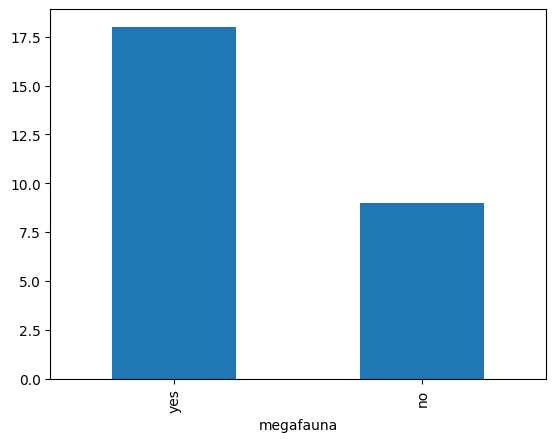

In [22]:
# Getting the distribution of animals by megafauna in a plot
print('-----------')
print(animals_gdf['megafauna'].value_counts())
print('-----------')
animals_gdf['megafauna'].value_counts().plot(kind='bar')

-----------
redlist_cat
Least Concern            15
Vulnerable                3
Endangered                3
Critically Endangered     3
Near Threatened           3
Name: count, dtype: int64
-----------


<Axes: xlabel='redlist_cat'>

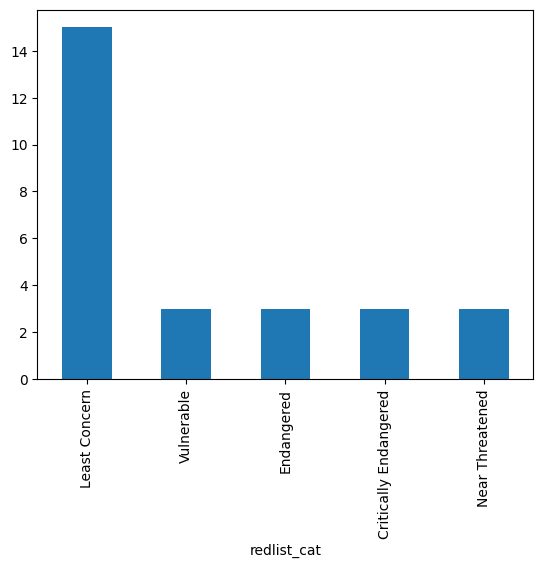

In [23]:
print('-----------')
print(animals_gdf['redlist_cat'].value_counts())
print('-----------')
animals_gdf['redlist_cat'].value_counts().plot(kind='bar')

How is the geographic distribution of animals?

- We can see cluster of animals around the different protected areas but it seems that most of the records show animals outside of the protected area

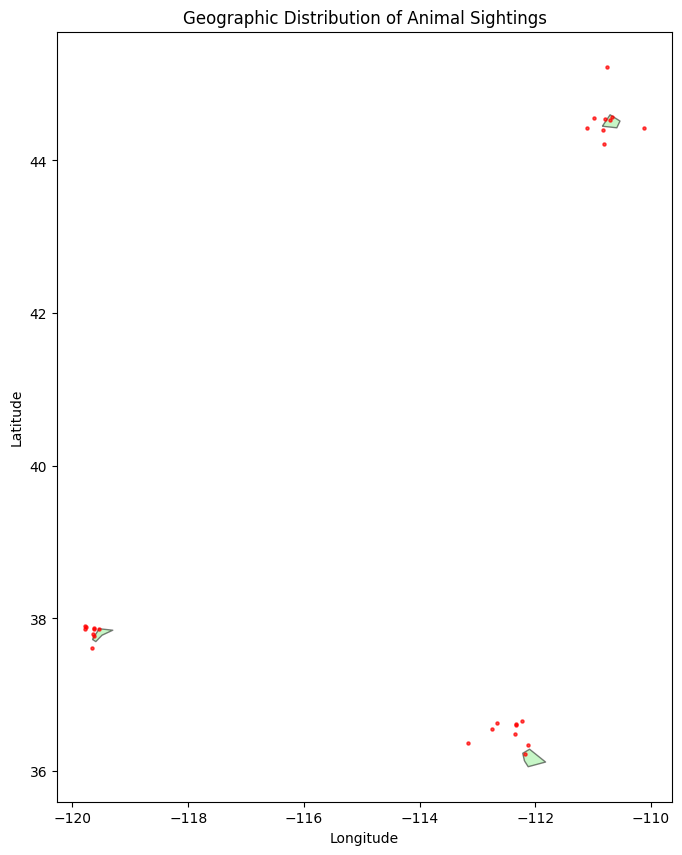

In [63]:
# Plotting the animal locations and protected areas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot protected areas
protected_areas_gdf.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

# Plot animal locations
animals_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.7)

plt.title('Geographic Distribution of Animal Sightings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Are there any geographic hotspots where multiple endangered or vulnerable species are located?

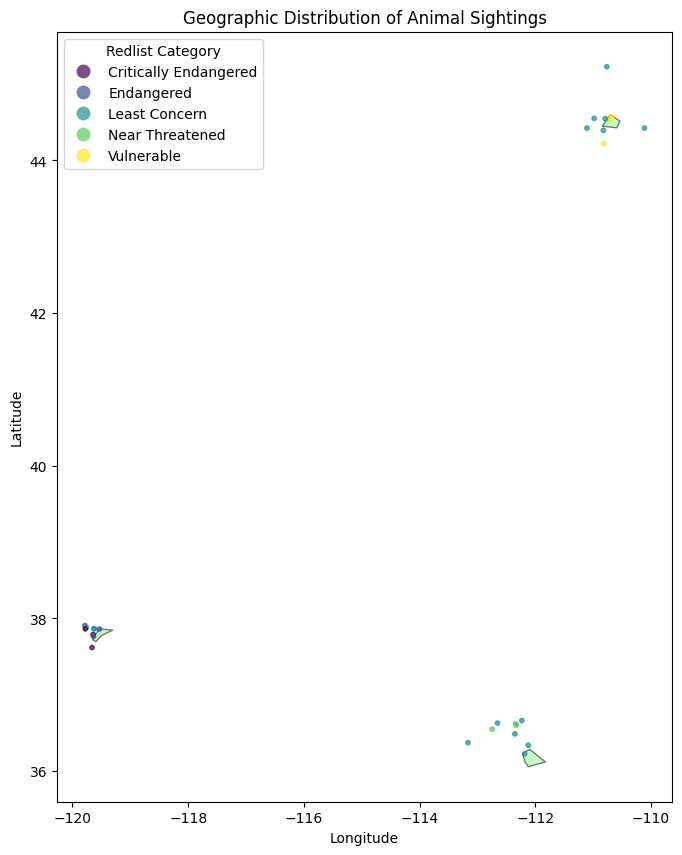

In [68]:
# Plotting the animal locations and protected areas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot protected areas
protected_areas_gdf.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5, label='Protected Areas')

# Plot animal locations with different colors based on redlist_cat
animal_plot = animals_gdf.plot(ax=ax, column='redlist_cat', cmap='viridis', markersize=10, alpha=0.7, legend=True)

# Adjust the legend for the redlist categories
legend1 = animal_plot.get_legend()
legend1.set_title('Redlist Category')

# Set titles and labels
plt.title('Geographic Distribution of Animal Sightings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


* We join protected_areas_gdf and animals_gdf to analize closer each area
* We also enumerate the different sightings to see how the movement happened

In [29]:
# Useful in future analisys
protected_areas_gdf['centroid_pa'] = protected_areas_gdf.geometry.centroid
# Join data
animals_parks = gpd.sjoin_nearest(animals_gdf, protected_areas_gdf, how='left')

# Enumerate events by animal_id and timestamp
animals_parks = animals_parks.sort_values(['animal_id', 'timestamp']).reset_index(drop=True)
animals_parks['rank'] = animals_parks.groupby('animal_id').cumcount() + 1
animals_parks.head()

/tmp/ipykernel_22/3081223265.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  protected_areas_gdf['centroid_pa'] = protected_areas_gdf.geometry.centroid
/usr/local/lib/python3.10/dist-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry,index_right,name,category,protected_area_id,centroid_pa,rank
0,A001,2024-09-01 12:00:00,45.2284,-110.7622,Wolf,Canis lupus,Least Concern,no,POINT (-110.7622 45.2284),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),1
1,A001,2024-09-01 13:00:00,44.3946,-110.8218,Wolf,Canis lupus,Least Concern,no,POINT (-110.8218 44.3946),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2
2,A001,2024-09-01 14:00:00,44.4246,-110.1118,Wolf,Canis lupus,Least Concern,no,POINT (-110.1118 44.4246),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),3
3,A002,2024-09-01 12:00:00,44.5760,-110.6763,Bison,Bison bison,Vulnerable,yes,POINT (-110.6763 44.576),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),1
4,A002,2024-09-01 13:00:00,44.5361,-110.7078,Bison,Bison bison,Vulnerable,yes,POINT (-110.7078 44.5361),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2


We create a function to see the data 
* We filter by protected area
* Create 3 subplots for each event
* We add text, legend and labels


We can see a lot of interesting patterns here
* For yellowstone we can see how the wolf moves around the protected area and both the elk and the bison move in oposite directions to it, it may indicate prey-hunter relationship altough the size can indicate the contrary
* For Yosemite we can see that the fox is moving fast, maybe hunting. Bobcat maintains a positions which can indicate that is in its territory
* Finally for Grand Canyon we can see how the Fox moves to the mule deer so maybe is also a prey - hunter relationship

In [45]:
def plot_animal_locations(animals_parks, protected_areas_gdf, park):
    # Filter the data for the specific park
    animals_parks = animals_parks[animals_parks['name'] == park]
    protected_areas_gdf = protected_areas_gdf[protected_areas_gdf['name'] == park]

    # Create a unique color for each common_name
    unique_names = animals_parks['common_name'].unique()
    colors = list(mcolors.TABLEAU_COLORS.values())
    color_dict = {name: colors[i % len(colors)] for i, name in enumerate(unique_names)}

    # Create 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(30, 10))

    # Plot protected areas on all subplots
    for ax in axes:
        protected_areas_gdf.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

    # Plot animal locations on each subplot based on the rank
    for rank, ax in zip([1, 2, 3], axes):
        rank_data = animals_parks[animals_parks['rank'] == rank]
        for _, row in rank_data.iterrows():
            ax.text(row['longitude'], row['latitude'], row['common_name'], fontsize=8, ha='center', va='bottom')
        rank_data.plot(ax=ax, column='common_name', categorical=True, cmap='tab20', markersize=10, alpha=0.7, legend=False)
        ax.set_title(f'Record {rank}')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    # Add the legend
    lines = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10, label=name) for name, color in color_dict.items()]
    plt.legend(handles=lines, loc='upper right', bbox_to_anchor=(1.4, 1))

    plt.suptitle('Geographic Distribution of Animal Sightings')
    plt.show()

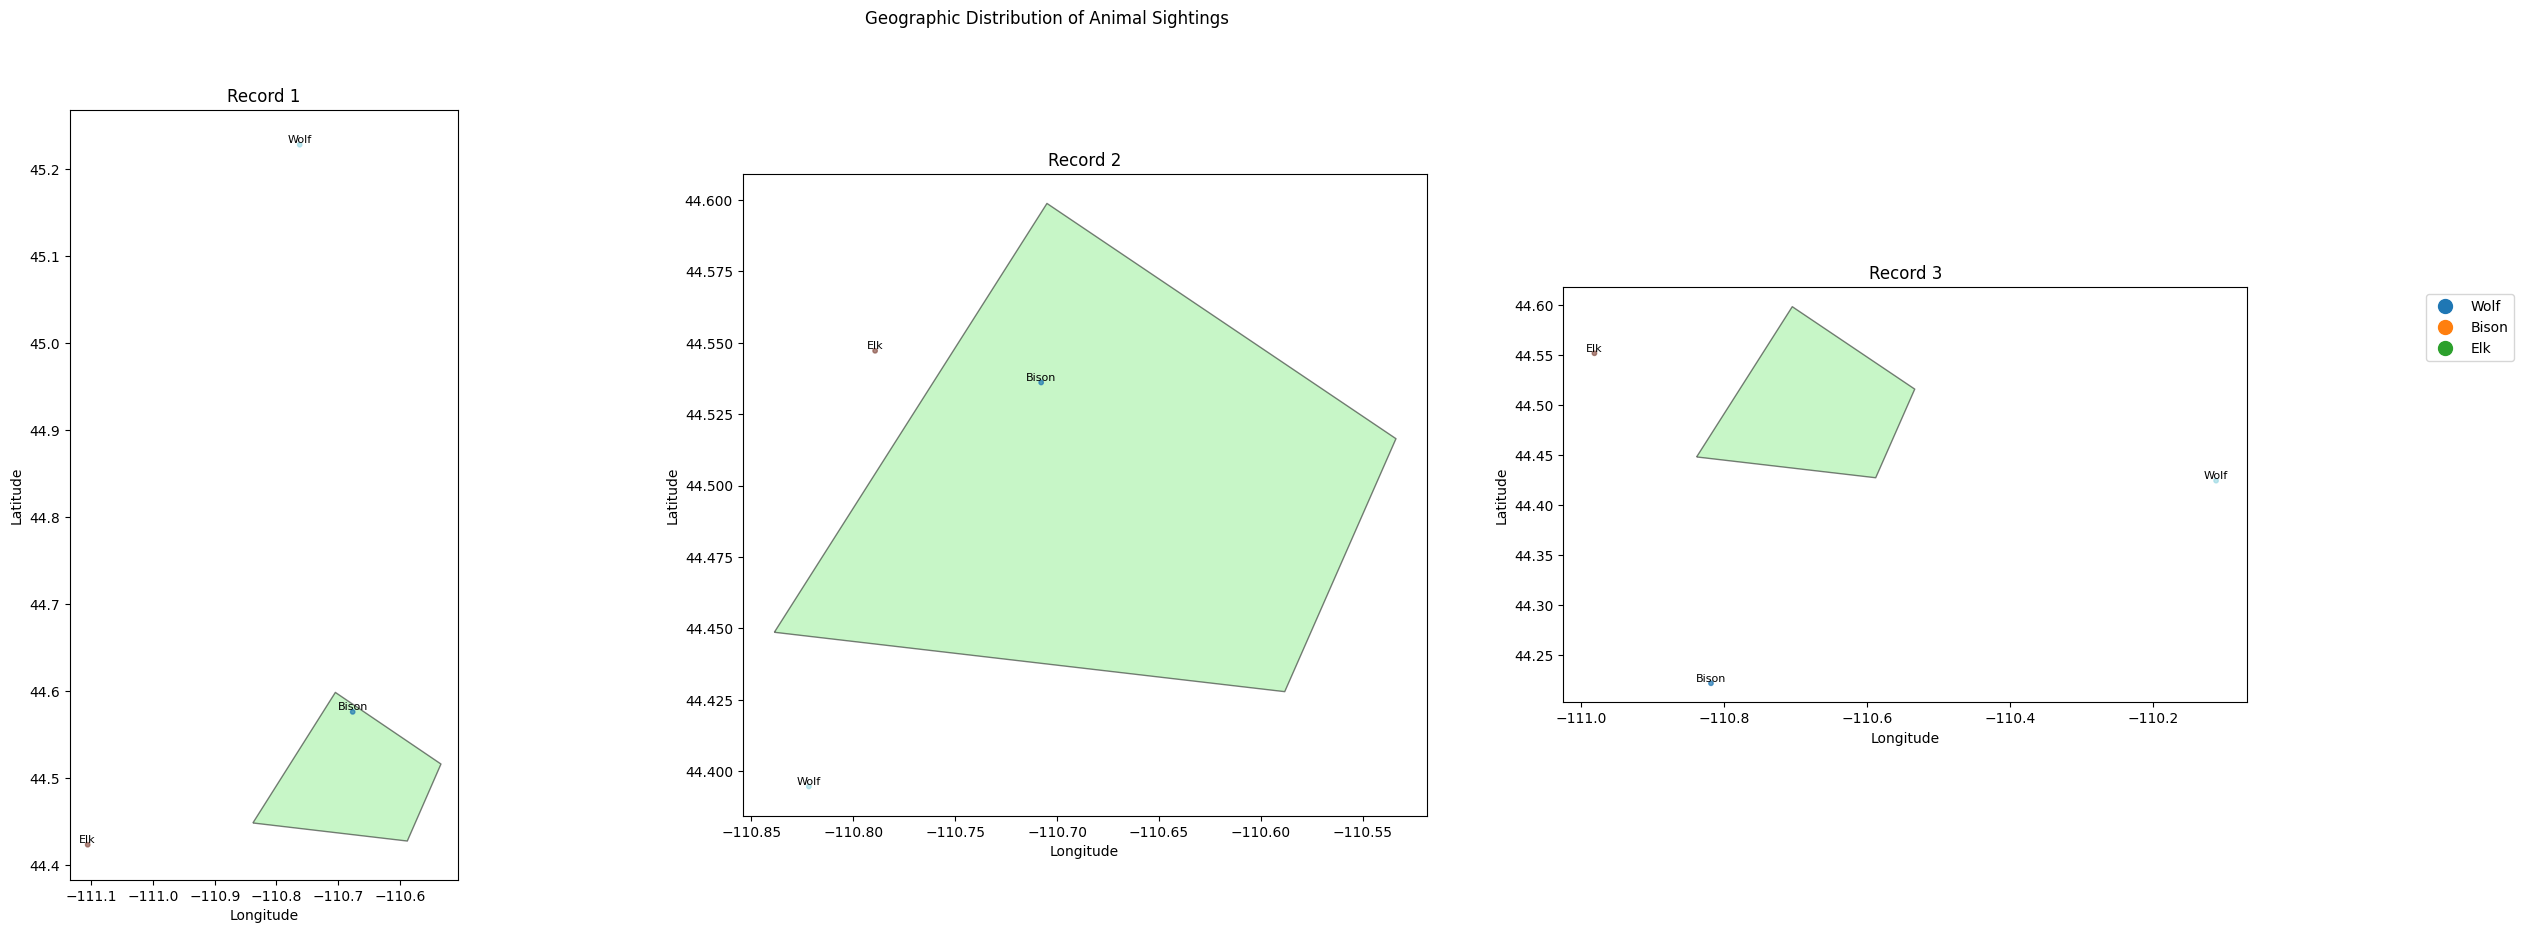

In [46]:
park = 'Yellowstone National Park'
plot_animal_locations(animals_parks, protected_areas_gdf, park)

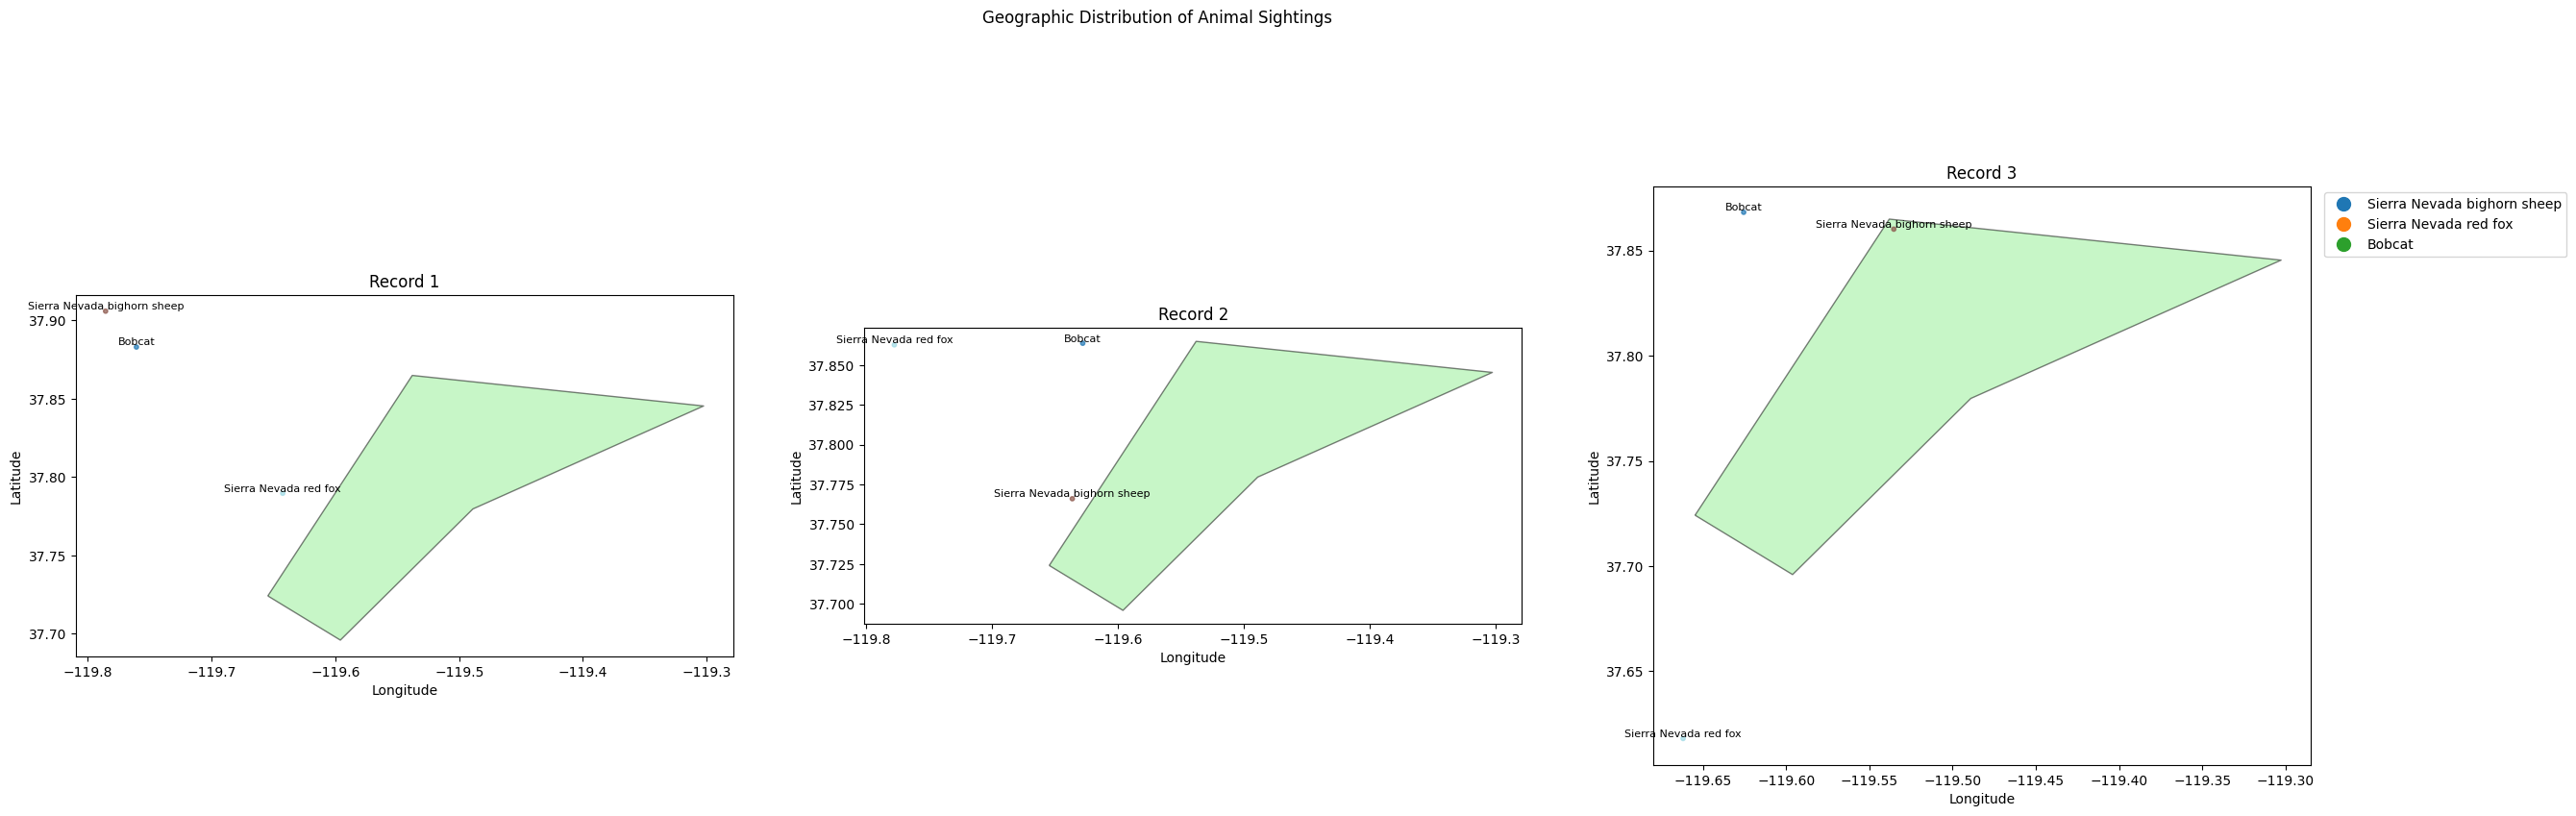

In [47]:
park = 'Yosemite National Park'
plot_animal_locations(animals_parks, protected_areas_gdf, park)

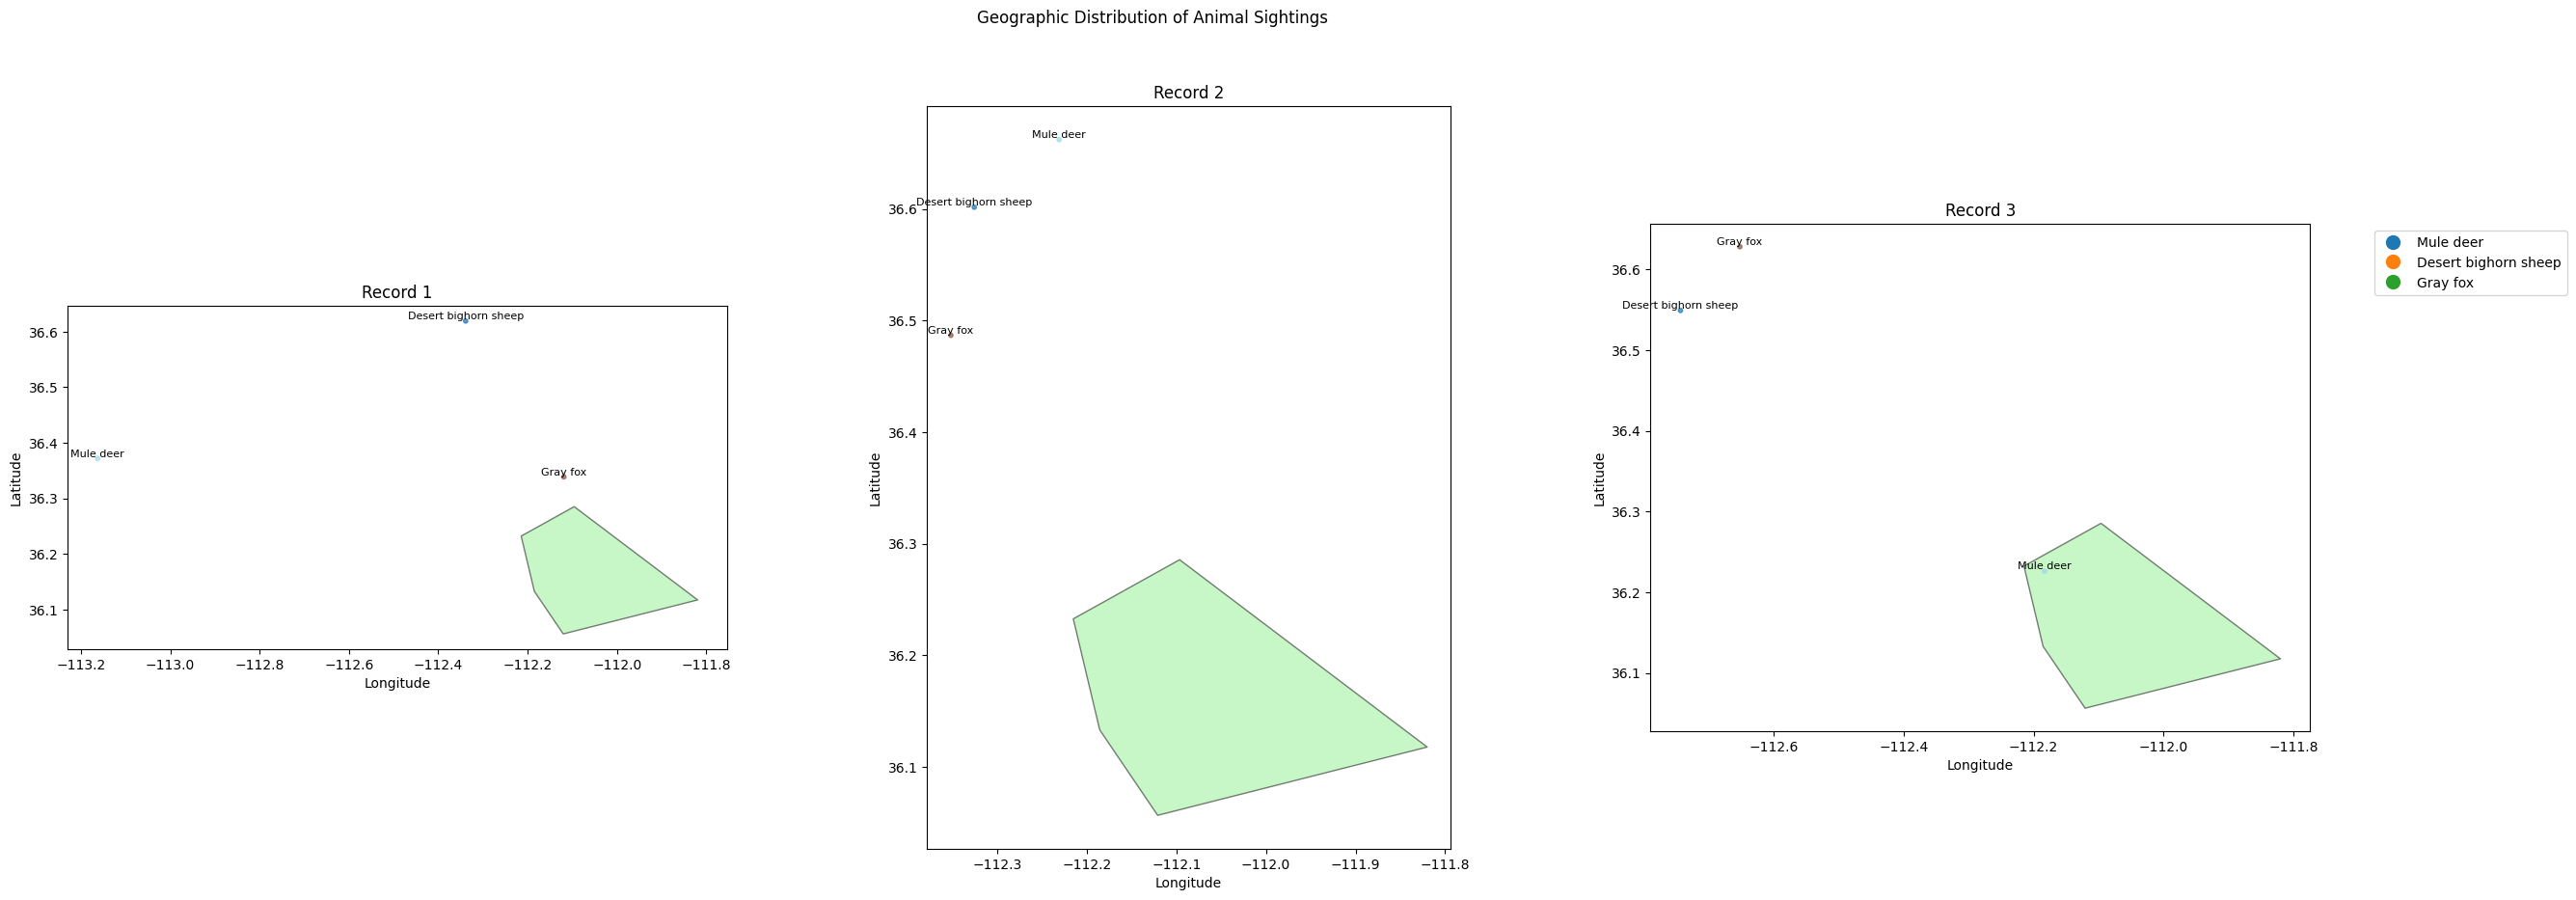

In [48]:
park = 'Grand Canyon National Park'
plot_animal_locations(animals_parks, protected_areas_gdf, park)

When does an animal cross the boudaries of the protected areas


In [50]:
# Spatial join to determine if each animal point is inside a protected area
animals_in_areas = gpd.sjoin(animals_gdf, protected_areas_gdf, how='left', predicate='within')

# Sort by animal_id and timestamp
animals_in_areas.sort_values(['animal_id', 'timestamp'], inplace=True)

# Shift the 'protected_area_id' to compare consecutive records
animals_in_areas['prev_protected_area_id'] = animals_in_areas.groupby('animal_id')['protected_area_id'].shift(1)

# Identify crossings
def identify_crossing(row):
    if pd.isnull(row['protected_area_id']) and not pd.isnull(row['prev_protected_area_id']):
        return 'Exit'
    elif not pd.isnull(row['protected_area_id']) and pd.isnull(row['prev_protected_area_id']):
        return 'Entry'
    else:
        return 'No Crossing'

animals_in_areas['crossing_type'] = animals_in_areas.apply(identify_crossing, axis=1)

# Filter for actual crossings
crossings_animals = animals_in_areas[animals_in_areas['crossing_type'].isin(['Entry', 'Exit', 'Boundary Crossing'])]

crossings_animals

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry,index_right,name,category,protected_area_id,centroid_pa,prev_protected_area_id,crossing_type
1,A002,2024-09-01 12:00:00,44.5760,-110.6763,Bison,Bison bison,Vulnerable,yes,POINT (-110.6763 44.576),0.0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),NaN,Entry
19,A002,2024-09-01 14:00:00,44.2221,-110.8182,Bison,Bison bison,Vulnerable,yes,POINT (-110.8182 44.2221),NaN,NaN,NaN,NaN,None,PA001,Exit
21,A004,2024-09-01 14:00:00,37.8601,-119.5353,Sierra Nevada bighorn sheep,Ovis canadensis sierrae,Endangered,no,POINT (-119.5353 37.8601),1.0,Yosemite National Park,National Park,PA002,POINT (-119.51326 37.79722),NaN,Entry
24,A007,2024-09-01 14:00:00,36.2261,-112.1831,Mule deer,Odocoileus hemionus,Least Concern,yes,POINT (-112.1831 36.2261),2.0,Grand Canyon National Park,National Park,PA003,POINT (-112.05483 36.1634),NaN,Entry


crossing_type  Entry  Exit
hour                      
12                 1     0
14                 2     1


/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


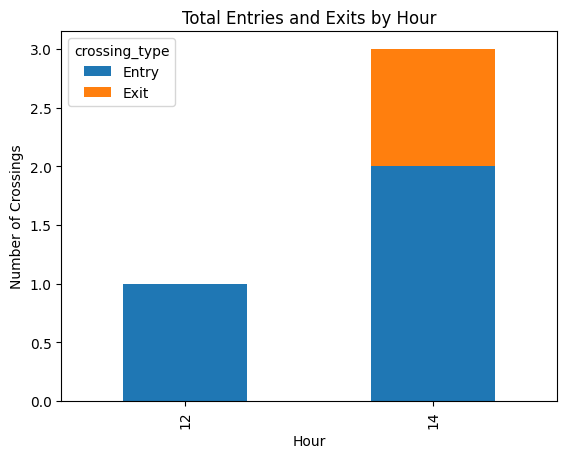

In [51]:
# Total crossings by hour
crossings_animals['hour'] = crossings_animals['timestamp'].dt.hour
total_crossings_per_hour = crossings_animals.groupby(['hour', 'crossing_type']).size().unstack(fill_value=0)
print(total_crossings_per_hour)

# Plot total crossings per hour
total_crossings_per_hour.plot(kind='bar', stacked=True, title='Total Entries and Exits by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Crossings')
plt.show()

### Advanced analysis

In [56]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

def plot_animal_trajectories(animals_parks, protected_areas_gdf, park):
    # Filter data for the specific park
    animals_filtered = animals_parks[animals_parks['name'] == park]
    protected_filtered = protected_areas_gdf[protected_areas_gdf['name'] == park]
    
    # Group by animal_id and create LineStrings
    trajectories = animals_filtered.groupby('animal_id')['geometry'].apply(lambda geom: LineString(geom.tolist()))
    traj_gdf = gpd.GeoDataFrame(trajectories, geometry='geometry', crs=animals_parks.crs)
    
    # Merge common_name into traj_gdf
    traj_gdf = traj_gdf.merge(
        animals_filtered[['animal_id', 'common_name']].drop_duplicates(),
        left_index=True, right_on='animal_id'
    )
    
    # Assign a unique color to each common_name
    unique_names = traj_gdf['common_name'].unique()
    colors = plt.cm.get_cmap('tab10', len(unique_names))
    color_dict = {name: colors(i) for i, name in enumerate(unique_names)}
    
    # Plot protected areas
    ax = protected_filtered.plot(color='lightgreen', edgecolor='black', figsize=(10, 10))
    
    # Plot each trajectory
    for _, row in traj_gdf.iterrows():
        traj = row['geometry']
        common_name = row['common_name']
        color = color_dict[common_name]
        traj_gdf_single = gpd.GeoSeries([traj])
        traj_gdf_single.plot(ax=ax, color=color, linewidth=2, label=common_name)
        
        # Enumerate and plot points
        for idx, point in enumerate(traj.coords, start=1):
            ax.plot(point[0], point[1], marker='o', color=color, markersize=5)
            ax.text(point[0], point[1], str(idx), fontsize=9, ha='right', va='bottom')
    
    # Create a legend without duplicate labels
    handles = []
    for name, color in color_dict.items():
        handles.append(plt.Line2D([], [], color=color, label=name))
    ax.legend(handles=handles, title='Common Names')
    
    # Add titles and labels
    plt.title('Animal Migration Paths')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_22/3038390636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


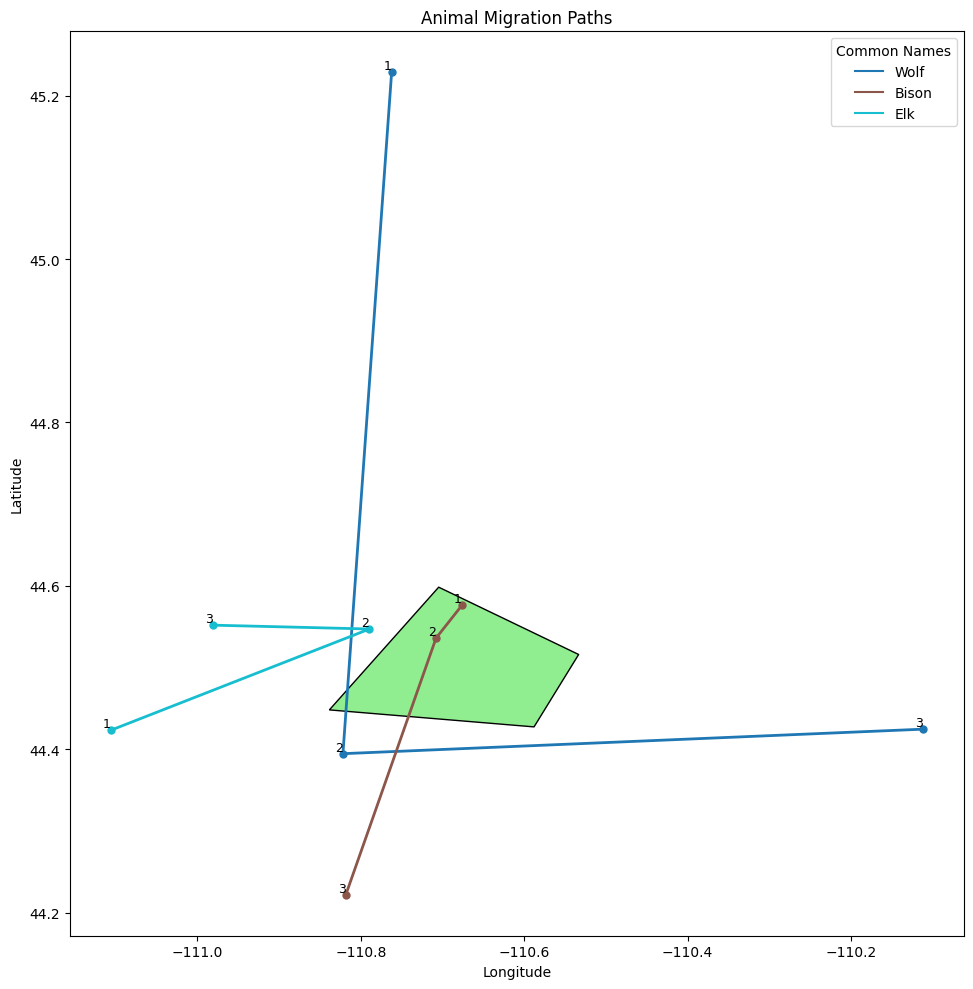

In [57]:
park = 'Yellowstone National Park'
plot_animal_trajectories(animals_parks, protected_areas_gdf, park)

/tmp/ipykernel_22/3038390636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


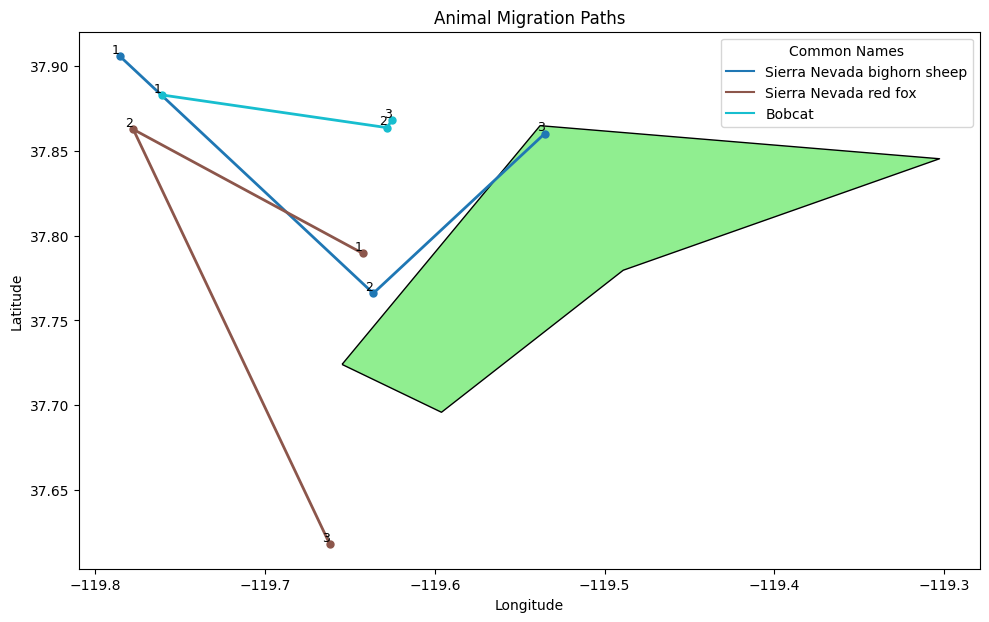

In [58]:
park = 'Yosemite National Park'
plot_animal_trajectories(animals_parks, protected_areas_gdf, park)

/tmp/ipykernel_22/3038390636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


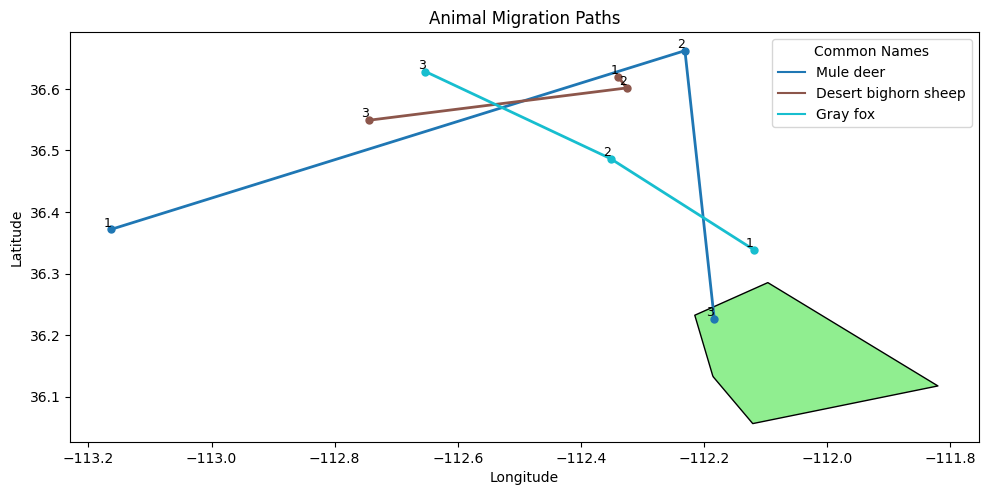

In [59]:
park = 'Grand Canyon National Park'
plot_animal_trajectories(animals_parks, protected_areas_gdf, park)

### Predicting animals migration

In this section I do the following
* Do feature engineering to get info about the last position of the data
* I handle categorical features
* Do a Random Forest algorithm to classify animals if they will move away

In [60]:
crossings_animals = crossings_animals.loc[:, ['animal_id', 'timestamp', 'crossing_type']]

crossings_animals = pd.merge(animals_parks, crossings_animals, on=['animal_id', 'timestamp'], how='left')

In [62]:
crossings_animals.head()

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry,index_right,name,category,protected_area_id,centroid_pa,rank,crossing_type
0,A001,2024-09-01 12:00:00,45.2284,-110.7622,Wolf,Canis lupus,Least Concern,no,POINT (-110.7622 45.2284),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),1,NaN
1,A001,2024-09-01 13:00:00,44.3946,-110.8218,Wolf,Canis lupus,Least Concern,no,POINT (-110.8218 44.3946),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2,NaN
2,A001,2024-09-01 14:00:00,44.4246,-110.1118,Wolf,Canis lupus,Least Concern,no,POINT (-110.1118 44.4246),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),3,NaN
3,A002,2024-09-01 12:00:00,44.5760,-110.6763,Bison,Bison bison,Vulnerable,yes,POINT (-110.6763 44.576),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),1,Entry
4,A002,2024-09-01 13:00:00,44.5361,-110.7078,Bison,Bison bison,Vulnerable,yes,POINT (-110.7078 44.5361),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2,NaN


In [71]:
# Ensure animal data is sorted
crossings_animals.sort_values(['animal_id', 'timestamp'], inplace=True)

# Create lag features for previous locations
crossings_animals['prev_latitude'] = crossings_animals.groupby('animal_id')['latitude'].shift(1)
crossings_animals['prev_longitude'] = crossings_animals.groupby('animal_id')['longitude'].shift(1)
crossings_animals['prev_timestamp'] = crossings_animals.groupby('animal_id')['timestamp'].shift(1)

# Calculate movement features
crossings_animals['delta_time'] = (crossings_animals['timestamp'] - crossings_animals['prev_timestamp']).dt.total_seconds()

# Drop rows with missing values due to shifting
crossings_animals.dropna(subset=['prev_latitude', 'prev_longitude', 'delta_time'], inplace=True)

In [72]:
crossings_animals.head()

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry,index_right,name,category,protected_area_id,centroid_pa,rank,crossing_type,prev_latitude,prev_longitude,prev_timestamp,delta_time
1,A001,2024-09-01 13:00:00,44.3946,-110.8218,Wolf,Canis lupus,Least Concern,no,POINT (-110.8218 44.3946),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2,NaN,45.2284,-110.7622,2024-09-01 12:00:00,3600.0
2,A001,2024-09-01 14:00:00,44.4246,-110.1118,Wolf,Canis lupus,Least Concern,no,POINT (-110.1118 44.4246),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),3,NaN,44.3946,-110.8218,2024-09-01 13:00:00,3600.0
4,A002,2024-09-01 13:00:00,44.5361,-110.7078,Bison,Bison bison,Vulnerable,yes,POINT (-110.7078 44.5361),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2,NaN,44.5760,-110.6763,2024-09-01 12:00:00,3600.0
5,A002,2024-09-01 14:00:00,44.2221,-110.8182,Bison,Bison bison,Vulnerable,yes,POINT (-110.8182 44.2221),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),3,Exit,44.5361,-110.7078,2024-09-01 13:00:00,3600.0
7,A003,2024-09-01 13:00:00,44.5472,-110.7893,Elk,Cervus canadensis,Least Concern,yes,POINT (-110.7893 44.5472),0,Yellowstone National Park,National Park,PA001,POINT (-110.6776 44.49933),2,NaN,44.4232,-111.1061,2024-09-01 12:00:00,3600.0


In [78]:
import numpy as np


# This function calculate the distance between 2 points
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c  # in kilometers
    return distance

# Calculate distance between previous and current position
crossings_animals['distance_km'] = crossings_animals.apply(lambda row: haversine_distance(
    row['prev_latitude'], row['prev_longitude'], row['latitude'], row['longitude']), axis=1)

In [127]:
# Calculating the speed
crossings_animals['delta_time_hours'] = crossings_animals['delta_time'] / 3600 
crossings_animals['speed_kmh'] = crossings_animals['distance_km'] / crossings_animals['delta_time_hours']

In [82]:
# Encode 'redlist_cat' and 'megafauna'
crossings_animals['redlist_cat_encoded'] = crossings_animals['redlist_cat'].astype('category').cat.codes
crossings_animals['megafauna_encoded'] = crossings_animals['megafauna'].map({'yes': 1, 'no': 0})

In [128]:
# Calculate distance to centroid of the nearest protected area
crossings_animals['distance_to_centroid_km'] = crossings_animals.apply(lambda row: haversine_distance(
    row['latitude'], row['longitude'], row['centroid_pa'].y, row['centroid_pa'].x), axis=1)

In [86]:
crossings_animals['hour'] = crossings_animals['timestamp'].dt.hour

In [91]:
# Shift latitude and longitude to get the next positions
crossings_animals['next_latitude'] = crossings_animals.groupby('animal_id')['latitude'].shift(-1)
crossings_animals['next_longitude'] = crossings_animals.groupby('animal_id')['longitude'].shift(-1)

# Drop rows where next positions are NaN
df_model = crossings_animals.dropna(subset=['next_latitude', 'next_longitude'])

# Features
features = [
    'latitude', 'longitude', 'speed_kmh',
    'prev_latitude', 'prev_longitude', 'hour',
    'redlist_cat_encoded', 'megafauna_encoded', 'distance_to_centroid_km'
]

# Target variables
target = ['next_latitude', 'next_longitude']

In [92]:
# Splitting the data

X = df_model[features]
y = df_model[target]

split_index = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [93]:
# Scaling numeric features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [95]:
from sklearn.metrics import mean_squared_error

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Calculate RMSE for latitude and longitude
rmse_lat = mean_squared_error(y_test['next_latitude'], y_pred[:, 0], squared=False)
rmse_lon = mean_squared_error(y_test['next_longitude'], y_pred[:, 1], squared=False)

print(f'RMSE Latitude: {rmse_lat}')
print(f'RMSE Longitude: {rmse_lon}')


RMSE Latitude: 2.1764095601610434
RMSE Longitude: 0.9915463116774544


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [111]:
# Predict future positions for the entire dataset
X_scaled = scaler.transform(X)
y_pred_all = model.predict(X_scaled)

# Add predictions to the DataFrame
df_model['predicted_next_latitude'] = y_pred_all[:, 0]
df_model['predicted_next_longitude'] = y_pred_all[:, 1]

# Create geometry column for predicted positions
df_model['predicted_geometry'] = df_model.apply(
    lambda row: Point(row['predicted_next_longitude'], row['predicted_next_latitude']), axis=1)

/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [112]:
df_model.head()

,animal_id,timestamp,latitude,longitude,common_name,scientific_name,redlist_cat,megafauna,geometry,index_right,...,speed_kmh,redlist_cat_encoded,megafauna_encoded,distance_to_centroid_km,hour,next_latitude,next_longitude,predicted_next_latitude,predicted_next_longitude,predicted_geometry
1,A001,2024-09-01 13:00:00,44.3946,-110.8218,Wolf,Canis lupus,Least Concern,no,POINT (-110.8218 44.3946),0,...,92.833453,2,0,16.329919,13,44.4246,-110.1118,43.734967,-110.765453,POINT (-110.76545 43.73497)
4,A002,2024-09-01 13:00:00,44.5361,-110.7078,Bison,Bison bison,Vulnerable,yes,POINT (-110.7078 44.5361),0,...,5.090521,4,1,4.737931,13,44.2221,-110.8182,44.038251,-111.082480,POINT (-111.08248 44.03825)
7,A003,2024-09-01 13:00:00,44.5472,-110.7893,Elk,Cervus canadensis,Least Concern,yes,POINT (-110.7893 44.5472),0,...,28.665586,2,1,10.332081,13,44.5519,-110.9812,44.188442,-111.101856,POINT (-111.10186 44.18844)
10,A004,2024-09-01 13:00:00,37.7660,-119.6363,Sierra Nevada bighorn sheep,Ovis canadensis sierrae,Endangered,no,POINT (-119.6363 37.766),1,...,20.341705,1,0,11.356992,13,37.8601,-119.5353,38.065026,-119.061034,POINT (-119.06103 38.06503)
13,A005,2024-09-01 13:00:00,37.8626,-119.7777,Sierra Nevada red fox,Vulpes vulpes necator,Critically Endangered,no,POINT (-119.7777 37.8626),1,...,14.376644,0,0,24.336088,13,37.6181,-119.6619,37.661720,-119.490042,POINT (-119.49004 37.66172)


I will modify the plot_animal_trajectories function to add predicted values and undertand predictions

* We can see that predictions are relatively good matematecally, however they do not seem natural, maybe more data would help to get better results


In [122]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

def plot_animal_trajectories(animals_parks, protected_areas_gdf, df_model, park):
    # Filter data for the specific park
    animals_filtered = animals_parks[animals_parks['name'] == park]
    protected_filtered = protected_areas_gdf[protected_areas_gdf['name'] == park]
    
    # Group by animal_id and create LineStrings
    trajectories = animals_filtered.groupby('animal_id')['geometry'].apply(lambda geom: LineString(geom.tolist()))
    traj_gdf = gpd.GeoDataFrame(trajectories, geometry='geometry', crs=animals_parks.crs)
    
    # Merge common_name into traj_gdf
    traj_gdf = traj_gdf.merge(
        animals_filtered[['animal_id', 'common_name']].drop_duplicates(),
        left_index=True, right_on='animal_id'
    )
    
    # Assign a unique color to each common_name
    unique_names = traj_gdf['common_name'].unique()
    colors = plt.cm.get_cmap('tab10', len(unique_names))
    color_dict = {name: colors(i) for i, name in enumerate(unique_names)}
    
    # Plot protected areas
    ax = protected_filtered.plot(color='lightgreen', edgecolor='black', figsize=(10, 10))
    
    # Plot each trajectory
    for _, row in traj_gdf.iterrows():
        traj = row['geometry']
        common_name = row['common_name']
        color = color_dict[common_name]
        traj_gdf_single = gpd.GeoSeries([traj])
        traj_gdf_single.plot(ax=ax, color=color, linewidth=2, label=common_name)
        
        # Enumerate and plot points
        for idx, point in enumerate(traj.coords, start=1):
            ax.plot(point[0], point[1], marker='o', color=color, markersize=5)
            ax.text(point[0], point[1], str(idx), fontsize=9, ha='right', va='bottom')
    
    # Plot predicted_geometry from df_model over the existing plot
    # Filter df_model for the specific park
    df_model_filtered = df_model[df_model['name'] == park]
    
    # Ensure df_model_filtered has 'predicted_geometry' and 'animal_id'
    if 'predicted_geometry' in df_model_filtered.columns:
        # Plot predicted positions
        for _, row in df_model_filtered.iterrows():
            animal_id = row['animal_id']
            predicted_point = row['predicted_geometry']
            common_name = row['common_name']
            color = color_dict.get(common_name, 'black')  # Default to black if not found
            
            # Plot predicted position with a distinct marker
            ax.plot(predicted_point.x, predicted_point.y, marker='x', color=color, markersize=8, label=f'{common_name} Predicted')
            ax.text(predicted_point.x, predicted_point.y, 'Predicted', fontsize=9, ha='left', va='bottom')
            
            # Optionally, draw a line from the last known position to the predicted position
            last_known_position = animals_filtered[animals_filtered['animal_id'] == animal_id]['geometry'].iloc[-1]
            prediction_line = LineString([last_known_position, predicted_point])
            gpd.GeoSeries([prediction_line]).plot(ax=ax, color=color, linestyle='--')
    
    # Create a legend without duplicate labels
    handles = []
    labels_seen = set()
    for name, color in color_dict.items():
        if name not in labels_seen:
            handles.append(plt.Line2D([], [], color=color, label=name))
            labels_seen.add(name)
    # Add a marker for predicted positions
    handles.append(plt.Line2D([], [], color='black', marker='x', linestyle='None', markersize=8, label='Predicted Position'))
    ax.legend(handles=handles, title='Common Names')
    
    # Add titles and labels
    plt.title(f'Animal Migration Paths in {park}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_22/1635888623.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


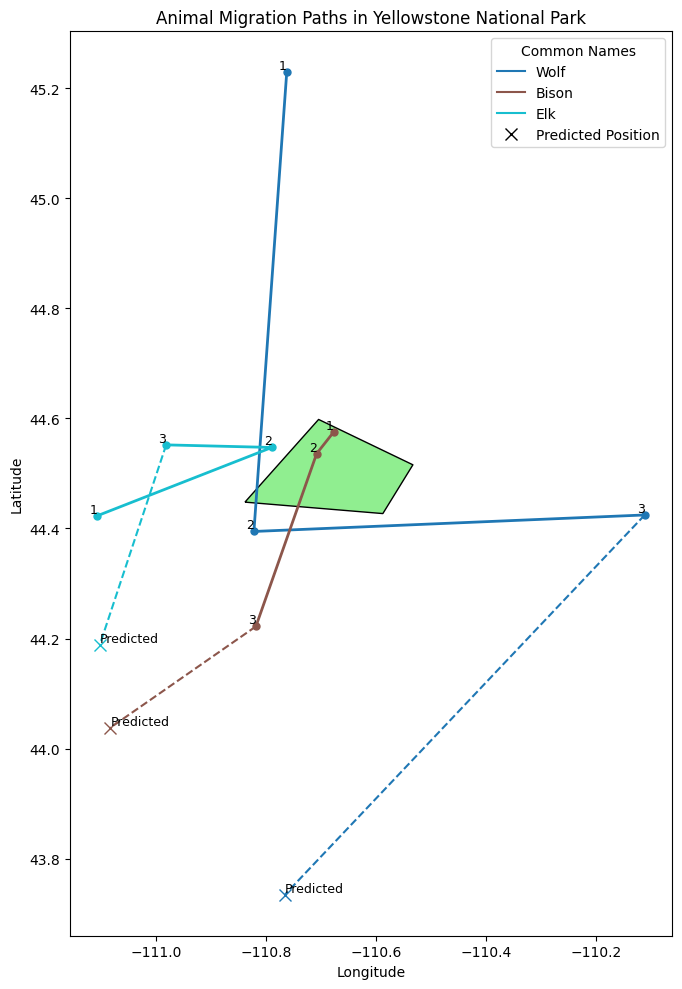

In [123]:
plot_animal_trajectories(animals_parks, protected_areas_gdf, df_model, 'Yellowstone National Park')

/tmp/ipykernel_22/1635888623.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


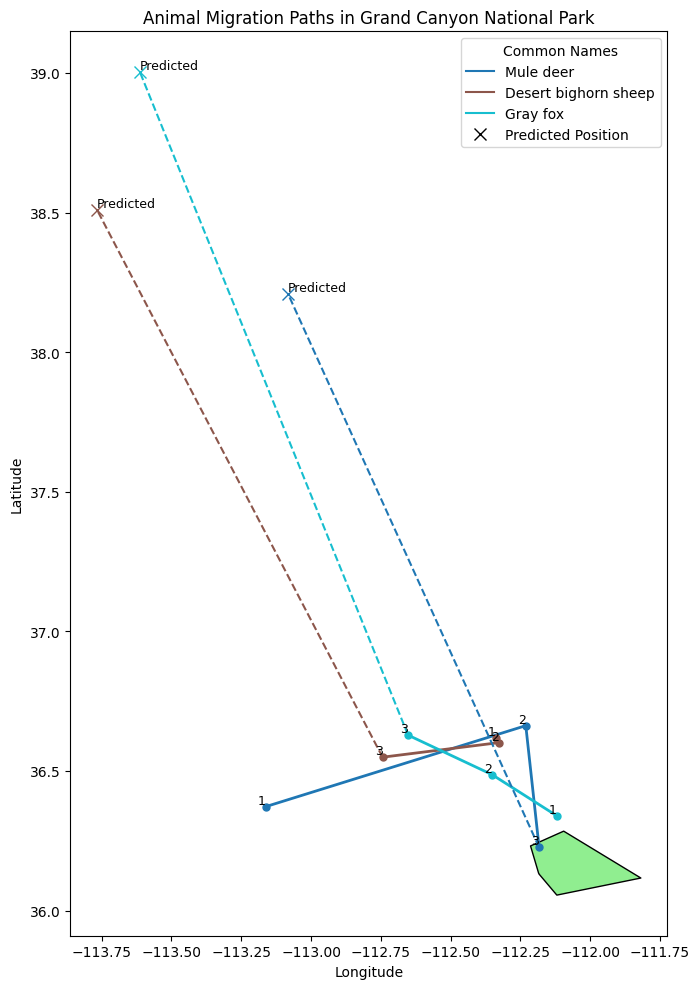

In [125]:
plot_animal_trajectories(animals_parks, protected_areas_gdf, df_model, 'Grand Canyon National Park')

/tmp/ipykernel_22/1635888623.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_names))


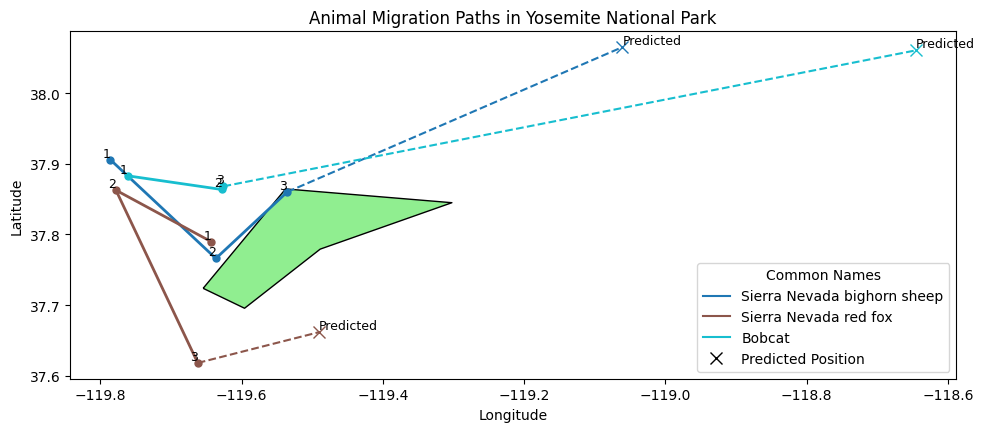

In [126]:
plot_animal_trajectories(animals_parks, protected_areas_gdf, df_model, 'Yosemite National Park')

## Conclusions:

* There is a balanced distribution between megafauna and non-megafauna species, with a slight prevalence of non-endangered species.
* Analysis of animal behavior within protected areas showed complex movement patterns, hinting at predator-prey relationships, territorial behaviors, and potential responses to external factors such as environmental changes.
* Movement analysis around parks like Yellowstone reveals potential hunter-prey dynamics, while fast movements of certain animals like the fox in Yosemite suggest hunting or territorial patrolling behaviors.
* The random forest model provided a reasonably accurate prediction of animal migration movements despite the limited data, however it has a lot of room for improvement
* Crossings tend to happen at specific hours, mainly around noon and afternoon (12 PM to 2 PM). This pattern can guide the timing of conservation patrols and monitoring.



Further Recommendations:
* Enhanced Data Monitoring: More data with more recent wildlife movement patterns and environmental factors can improve the accuracy of future predictions.
* Model Refinement: Incorporating additional features, such as weather data, vegetation type, and human activities, could enhance the predictive model's accuracy for future migrations.